In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nDataset Information")
df.info()

print("\nMissing Value Check")
missing = df.isnull().sum().sum()

if missing == 0:
    print("No Missing Values Found")
else:
    print(f"Missing Values Found: {missing}")

correlation = df.corr()["target"].drop("target").abs().sort_values(ascending=False)

top_features = correlation.head(5).index.tolist()

print("\nTop 5 Selected Features")
print(top_features)

X = df[top_features]
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=top_features)

print("\nScaled Features")
display(X_scaled.head())

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Dataset Shape: (569, 31)

First 5 Rows


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

,worst concave points,worst perimeter,mean concave points,worst radius,mean perimeter
0,2.296076,2.303601,2.532475,1.886690,1.269934
1,1.087084,1.535126,0.548144,1.805927,1.685955
2,1.955000,1.347475,2.037231,1.511870,1.566503
3,2.175786,-0.249939,1.451707,-0.281464,-0.592687
4,0.729259,1.338539,1.428493,1.298575,1.776573



Training Shape : (455, 5)
Testing Shape  : (114, 5)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

dt_params = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10]
}

gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3]
}

svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_
gb_model = gb_grid.best_estimator_
svm_model = svm_grid.best_estimator_

print("Decision Tree Best Parameters")
print(dt_grid.best_params_)

print("\nGradient Boosting Best Parameters")
print(gb_grid.best_params_)

print("\nSVM Best Parameters")
print(svm_grid.best_params_)

dt_pred = dt_model.predict(X_test)
gb_pred = gb_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]
svm_prob = svm_model.predict_proba(X_test)[:, 1]

Decision Tree Best Parameters
{'max_depth': 4, 'min_samples_split': 10}

Gradient Boosting Best Parameters
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}

SVM Best Parameters
{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [3]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

models = [
    ("Decision Tree", dt_model, dt_pred, dt_prob),
    ("Gradient Boosting", gb_model, gb_pred, gb_prob),
    ("SVM", svm_model, svm_pred, svm_prob)
]

for name, model, pred, prob in models:

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    results.loc[len(results)] = [
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

print("Model Performance Comparison")

display(results.round(4))

best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Performing Model :", best_model)

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.8947,0.9545,0.8750,0.9130,0.9228
1,Gradient Boosting,0.9386,0.9577,0.9444,0.9510,0.9835
2,SVM,0.9649,0.9722,0.9722,0.9722,0.9931



Best Performing Model : SVM


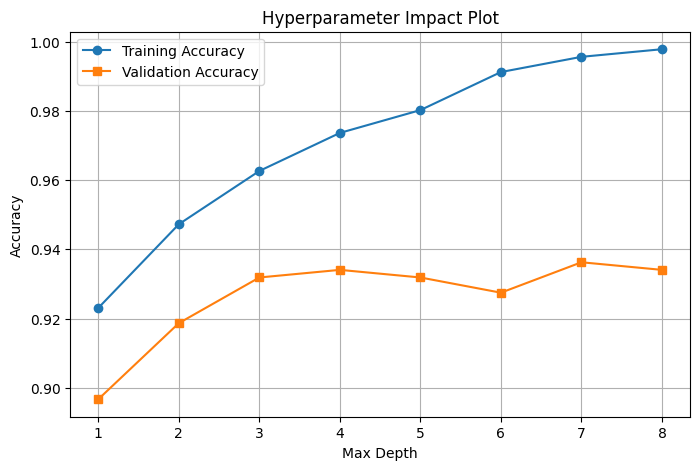

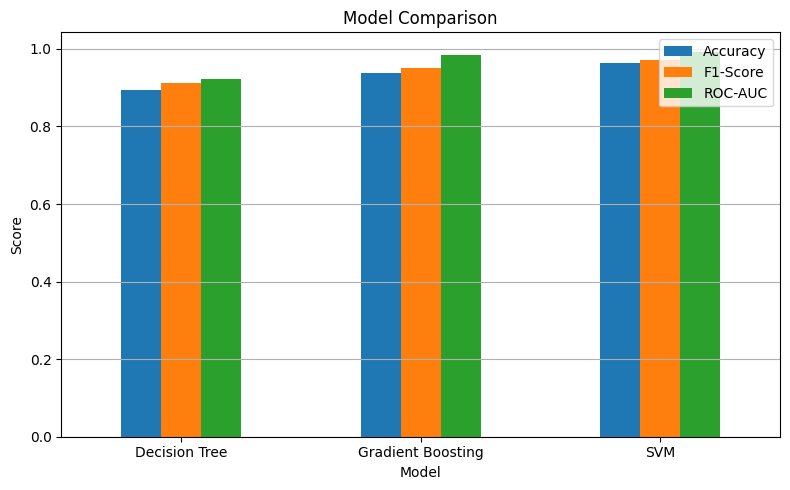

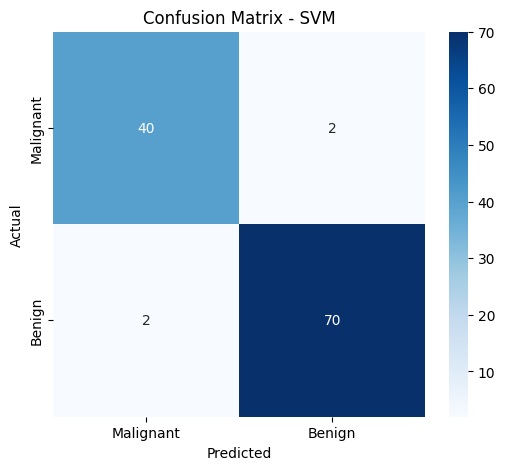

Final Performance Summary


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,SVM,0.9649,0.9722,0.9722,0.9722,0.9931
1,Gradient Boosting,0.9386,0.9577,0.9444,0.9510,0.9835
0,Decision Tree,0.8947,0.9545,0.8750,0.9130,0.9228



Best Performing Model : SVM


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

depths = [1, 2, 3, 4, 5, 6, 7, 8]

train_acc = []
val_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    val_acc.append(score)

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker="o", label="Training Accuracy")
plt.plot(depths, val_acc, marker="s", label="Validation Accuracy")
plt.title("Hyperparameter Impact Plot")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("hyperparameter_impact.png")
plt.show()

plot_data = results.set_index("Model")[["Accuracy","F1-Score","ROC-AUC"]]

plot_data.plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

if best_model == "Decision Tree":
    best = dt_model
    pred = dt_pred
elif best_model == "Gradient Boosting":
    best = gb_model
    pred = gb_pred
else:
    best = svm_model
    pred = svm_pred

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"]
)

plt.title(f"Confusion Matrix - {best_model}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

print("="*60)
print("Final Performance Summary")
print("="*60)

display(results.sort_values(by="Accuracy", ascending=False).round(4))

print("\nBest Performing Model :", best_model)